# Session 1 — Introduction to AnnData and dataset integration

This notebook introduces the core data structure used in single-cell analysis (**AnnData**) and walks through loading, exploring, and merging two endometrial scRNA-seq datasets.

Both datasets profile the **human endometrium** using **Chromium 10x 3' scRNA-seq**.

---

**Activity 1** — Load and explore each dataset independently.
Understand the AnnData structure (`.X`, `.obs`, `.var`) and the metadata it holds.

**Activity 2** — Merge the two datasets.
Explore inner vs. outer join on the gene space and visualise donor distribution.

**Activity Extra** — What happens when datasets don't align perfectly?
Explore shared cell barcodes and missing metadata columns.

---

**Datasets used:**
| | Dataset | Cells | Genes | Platform | GEO |
|-|---------|-------|-------|----------|-----|
| 1 | Wang et al. 2020 | 25,971 | 32,483 | 10x Chromium 3' | GSE111976 |
| 2 | Burns et al. 2026 | 35,930 | 31,280 | 10x Chromium 3' | GSE290822 |

In [1]:
# --- Optional: run this block only if you are working in Google Colab ---
# import sys
# IN_COLAB = "google.colab" in sys.modules
# if IN_COLAB:
#     from google.colab import drive; drive.mount('/content/drive')
#     %run /content/drive/MyDrive/immerge_workshop/codes/notebooks/setup_notebook.py

---
# Activity 1 — Exploring individual datasets

In [2]:
# Single-cell analysis
import anndata as ad
import scanpy as sc

# General data handling
import pandas as pd
import numpy as np

# Dataset 1: Wang et al. 2020

We start by loading the first dataset and exploring the **AnnData** object — the core data structure used in single-cell analysis.

An AnnData object holds:
| Attribute | Contents |
|-----------|----------|
| `.X` | Expression matrix — cells × genes |
| `.obs` | Per-cell metadata (one row per cell) |
| `.var` | Per-gene metadata (one row per gene) |
| `.obsm` | Dimensionality reductions (PCA, UMAP…) |
| `.uns` | Unstructured data (colour palettes, settings…) |

### Load

In [3]:
file_dataset1 = '/nfs/team292/projects/immerge_workshop/data/wang_f_2020.h5ad'
adata_dataset1 = ad.read_h5ad(file_dataset1)

### Explore the AnnData object

Printing the object gives a quick summary: number of cells (`n_obs`), number of genes (`n_vars`), and which metadata fields are populated.

In [4]:
adata_dataset1

AnnData object with n_obs × n_vars = 25971 × 32483
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors'

`.X` is the expression matrix. Its shape confirms `(n_cells, n_genes)`.

In [5]:
adata_dataset1.X.shape

(25971, 32483)

### Explore `.obs` — cell metadata

Each row in `.obs` corresponds to one cell. Columns hold QC metrics, cell-cycle scores, donor info, and experimental annotations.

In [6]:
adata_dataset1.obs.head()

,n_genes,percent_mito,doublet_scores,senescence_score,stress_score_vandenBrink,health_score,metabolic_activity,S_score,G2M_score,phase,...,Sorting_method,Assay_type,Library_chemistry,Sequencing_platform,Multiplexed,Dataset_id,Batch,Collection_site,Sample_id_other,Menstrual_stage_OriginalAuthors
GSM4577307_TACTTACCAAGACCTT-1,12448,0.023902,0.128492,9.203672,36.147962,131.065271,14.622414,-11.147454,-1.463197,G1,...,Not applicable,10x scRNA-seq,3' v3.1,novaseq6000,no,GSE111976,unknown,Standford University,GSM4577307,Proliferative
GSM4577307_ATCGCCTGTCACAATC-1,11276,0.048520,0.076923,25.261842,40.423467,110.751642,17.037356,-11.555573,-2.902986,G1,...,Not applicable,10x scRNA-seq,3' v3.1,novaseq6000,no,GSE111976,unknown,Standford University,GSM4577307,Proliferative
GSM4577307_TTGCATTAGAGTCACG-1,11559,0.045680,0.102894,9.385677,43.772553,123.134647,9.513218,-11.860242,-1.231261,G1,...,Not applicable,10x scRNA-seq,3' v3.1,novaseq6000,no,GSE111976,unknown,Standford University,GSM4577307,Proliferative
GSM4577307_ATTCTACCAGTAACAA-1,12198,0.068217,0.215259,6.305834,27.328331,45.709360,-1.795402,-5.955790,-2.449373,G1,...,Not applicable,10x scRNA-seq,3' v3.1,novaseq6000,no,GSE111976,unknown,Standford University,GSM4577307,Proliferative
GSM4577307_ACTTATCAGCGTGTTT-1,11441,0.058485,0.122744,6.572938,28.294078,106.761494,14.361494,-3.956719,0.227943,G2M,...,Not applicable,10x scRNA-seq,3' v3.1,novaseq6000,no,GSE111976,unknown,Standford University,GSM4577307,Proliferative


List all `.obs` column names and confirm that `Donor_id`, `Dataset`, and `Menstrual_stage` are present — we'll rely on these for downstream comparisons.

In [7]:
# obs_keys() returns a list of all column names in .obs
adata_dataset1.obs_keys()

/tmp/ipykernel_3529122/4137267139.py:2: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  adata_dataset1.obs_keys()


['n_genes',
 'percent_mito',
 'doublet_scores',
 'senescence_score',
 'stress_score_vandenBrink',
 'health_score',
 'metabolic_activity',
 'S_score',
 'G2M_score',
 'phase',
 'sample',
 'dataset',
 'in_HCAv1',
 'exclusion-inclusion_criteria',
 'Organ',
 'Dataset',
 'Sample_id',
 'Library_id',
 'Donor_id',
 'Sex',
 'Postnatal_age_years',
 'Gestational_age_pcw',
 'Developmental_stage',
 'Tanner Stage',
 'Menstrual_stage',
 'Disease',
 'Clinical_diagnosis',
 'Organ_part',
 'Tissue_ROI',
 'Specimen_type',
 'Sampled_site_condition',
 'Observed_pathology',
 'Tissue_status',
 'Dissociation_method',
 'Cell_enrichment',
 'Preservation_method',
 'Target_cell_population',
 'Sorting_method',
 'Assay_type',
 'Library_chemistry',
 'Sequencing_platform',
 'Multiplexed',
 'Dataset_id',
 'Batch',
 'Collection_site',
 'Sample_id_other',
 'Menstrual_stage_OriginalAuthors']

In [8]:
adata_dataset1.obs["Donor_id"].value_counts(dropna=False)

Donor_id
SAMN15049047    13328
SAMN15049042     4466
SAMN15049046     4296
SAMN15049050     3881
Name: count, dtype: int64

In [9]:
adata_dataset1.obs["Dataset"].value_counts(dropna=False)

Dataset
Wang 2020    25971
Name: count, dtype: int64

In [10]:
adata_dataset1.obs["Menstrual_stage"].value_counts(dropna=False)

Menstrual_stage
Secretory        17624
Proliferative     8347
Name: count, dtype: int64

Cross-tabulate donors by menstrual stage to see the experimental design.

In [11]:
df = adata_dataset1.obs[["Menstrual_stage", "Donor_id"]].drop_duplicates()
pd.crosstab(df["Menstrual_stage"], df["Donor_id"])

Donor_id,SAMN15049042,SAMN15049046,SAMN15049047,SAMN15049050
Menstrual_stage,,,,
Proliferative,1,0,0,1
Secretory,0,1,1,0


### Explore `.var` — gene metadata

`.var` stores per-gene information. The index (row labels) shows how genes are named — here, **gene symbols** (e.g. `A1BG`) rather than Ensembl IDs.

In [12]:
adata_dataset1.var.head()

""
A1BG
A1BG-AS1
A1CF
A2M
A2M-AS1


# Dataset 2: Burns et al. 2026

We repeat the same exploration steps for the second dataset before merging. Pay attention to differences in cell count, donor IDs, and menstrual stage labels.

### Load

In [13]:
file_dataset2 = '/nfs/team292/projects/immerge_workshop/data/burns_f_2026.h5ad'
adata_dataset2 = ad.read_h5ad(file_dataset2)

### Explore AnnData

In [14]:
adata_dataset2

AnnData object with n_obs × n_vars = 35930 × 31280
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors'

Check size of the matrix

In [15]:
adata_dataset2.X.shape

(35930, 31280)

### Explore .obs
Explore cells and sample information

In [16]:
adata_dataset2.obs.head()

,n_genes,percent_mito,doublet_scores,senescence_score,stress_score_vandenBrink,health_score,metabolic_activity,S_score,G2M_score,phase,...,Sorting_method,Assay_type,Library_chemistry,Sequencing_platform,Multiplexed,Dataset_id,Batch,Collection_site,Sample_id_other,Menstrual_stage_OriginalAuthors
GSM8823442_GACGTTAAGAATCCCT-1,12379,0.038100,0.154696,16.335423,56.602705,244.628571,67.050000,1.869305,2.092977,G2M,...,Not applicable,10x scRNA-seq,3' v2,nextseq500,no,GSE290822,unknown,Rutgers - New Jersey Medical School,GSM8823442,Secretory Early
GSM8823442_CCAATTTCAGGTTCCG-1,12094,0.058168,0.104762,8.267534,51.125782,158.077619,32.863333,-3.324084,-6.217057,G1,...,Not applicable,10x scRNA-seq,3' v2,nextseq500,no,GSE290822,unknown,Rutgers - New Jersey Medical School,GSM8823442,Secretory Early
GSM8823442_TCCTGCATCCGCAAAT-1,12219,0.039623,0.096386,4.553537,44.510989,207.629048,9.210000,-10.347208,-12.295652,G1,...,Not applicable,10x scRNA-seq,3' v2,nextseq500,no,GSE290822,unknown,Rutgers - New Jersey Medical School,GSM8823442,Secretory Early
GSM8823442_GTATTTCGTAGCTCGC-1,11149,0.033702,0.117446,4.014368,27.520287,281.402857,42.743333,-6.531346,-7.424582,G1,...,Not applicable,10x scRNA-seq,3' v2,nextseq500,no,GSE290822,unknown,Rutgers - New Jersey Medical School,GSM8823442,Secretory Early
GSM8823442_GGGTATTCAGAACCGA-1,11661,0.070126,0.104762,4.812617,41.431488,159.121429,13.466667,-9.857143,-9.026756,G1,...,Not applicable,10x scRNA-seq,3' v2,nextseq500,no,GSE290822,unknown,Rutgers - New Jersey Medical School,GSM8823442,Secretory Early


Check that the same key columns exist in Dataset 2.

In [17]:
adata_dataset2.obs_keys()

/tmp/ipykernel_3529122/29892141.py:1: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  adata_dataset2.obs_keys()


['n_genes',
 'percent_mito',
 'doublet_scores',
 'senescence_score',
 'stress_score_vandenBrink',
 'health_score',
 'metabolic_activity',
 'S_score',
 'G2M_score',
 'phase',
 'sample',
 'dataset',
 'in_HCAv1',
 'exclusion-inclusion_criteria',
 'Organ',
 'Dataset',
 'Sample_id',
 'Library_id',
 'Donor_id',
 'Sex',
 'Postnatal_age_years',
 'Gestational_age_pcw',
 'Developmental_stage',
 'Tanner Stage',
 'Menstrual_stage',
 'Disease',
 'Clinical_diagnosis',
 'Organ_part',
 'Tissue_ROI',
 'Specimen_type',
 'Sampled_site_condition',
 'Observed_pathology',
 'Tissue_status',
 'Dissociation_method',
 'Cell_enrichment',
 'Preservation_method',
 'Target_cell_population',
 'Sorting_method',
 'Assay_type',
 'Library_chemistry',
 'Sequencing_platform',
 'Multiplexed',
 'Dataset_id',
 'Batch',
 'Collection_site',
 'Sample_id_other',
 'Menstrual_stage_OriginalAuthors']

In [18]:
adata_dataset2.obs["Donor_id"].value_counts(dropna=False)

Donor_id
EMB52    9774
EMB51    9233
EMB53    8863
EMB87    8060
Name: count, dtype: int64

In [19]:
adata_dataset2.obs["Dataset"].value_counts(dropna=False)

Dataset
Burns 2026    35930
Name: count, dtype: int64

In [20]:
adata_dataset2.obs["Menstrual_stage"].value_counts(dropna=False)

Menstrual_stage
Proliferative    18096
Secretory        17834
Name: count, dtype: int64

Cross-tabulate donors by menstrual stage — note the stage labels differ from Dataset 1.

In [21]:
df = adata_dataset2.obs[["Menstrual_stage", "Donor_id"]].drop_duplicates()
pd.crosstab(df["Menstrual_stage"], df["Donor_id"])

Donor_id,EMB51,EMB52,EMB53,EMB87
Menstrual_stage,,,,
Proliferative,1,0,1,0
Secretory,0,1,0,1


### Explore `.var` — gene names in Dataset 2

Are the genes named the same way as in Dataset 1? This matters for merging.

In [22]:
adata_dataset2.var.head()

""
A1BG
A1BG-AS1
A1CF
A2M
A2M-AS1


---
# Activity 2 — Merging datasets

### Concatenate the two datasets

We stack cells (rows) from both datasets. The `join` parameter controls how genes (columns) that differ between datasets are handled:

| `join` | Genes kept | Missing values in `.X` |
|--------|-----------|------------------------|
| `'outer'` | All genes from both datasets | `NaN` where a gene is absent |
| `'inner'` | Only genes present in **both** | None |

In [23]:
# Outer join — all genes retained; cells missing a gene get NaN
adata_outer = ad.concat([adata_dataset1, adata_dataset2], join='outer')
adata_outer

AnnData object with n_obs × n_vars = 61901 × 32837
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors'

In [24]:
# Inner join — only shared genes; no missing values in .X
adata_inner = ad.concat([adata_dataset1, adata_dataset2], join='inner')
adata_inner

AnnData object with n_obs × n_vars = 61901 × 30926
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors'

## Gene overlap between datasets

The two datasets were sequenced independently and may cover slightly different gene sets. Let's quantify the overlap to understand how much information is lost when using an inner join.

In [25]:
genes1 = set(adata_dataset1.var_names)
genes2 = set(adata_dataset2.var_names)

Genes present in **both** datasets (set intersection).

In [26]:
shared_genes = genes1 & genes2

Genes exclusive to each dataset (set difference).

In [27]:
specific_to_dataset1 = genes1 - genes2
specific_to_dataset2 = genes2 - genes1

Summarise the counts — `shared_genes` should match `adata_inner.n_vars`.

In [28]:
print(f"Shared genes:            {len(shared_genes)}")
print(f"Dataset1-specific genes: {len(specific_to_dataset1)}")
print(f"Dataset2-specific genes: {len(specific_to_dataset2)}")

Shared genes:            30926
Dataset1-specific genes: 1557
Dataset2-specific genes: 354


In [29]:
# Sanity check: should equal len(shared_genes) above
adata_inner.n_vars

30926

In [30]:
'BPIFA1' in shared_genes

False

In [31]:
'BPIFA1' in specific_to_dataset1

True

### Cells distribution per menstrual stage & dataset

How many cells each dataset contributes to each menstrual stage?

In [32]:
pd.crosstab(adata_inner.obs["Menstrual_stage"], adata_inner.obs["Dataset"])

Dataset,Burns 2026,Wang 2020
Menstrual_stage,,
Proliferative,18096,8347
Secretory,17834,17624


/tmp/ipykernel_3529122/2694984709.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Menstrual_stage"])


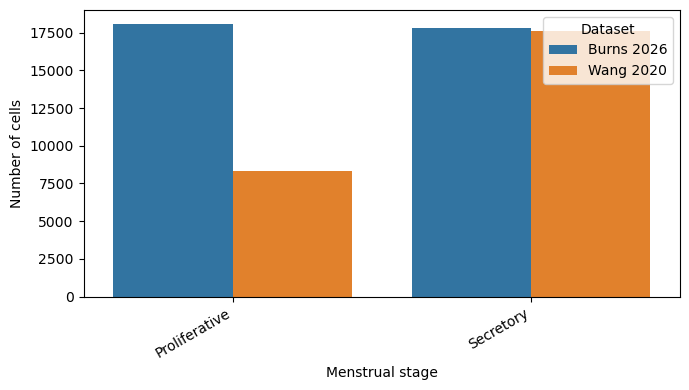

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count cells per menstrual stage and dataset
df_plot = (
    adata_inner.obs
    .groupby(["Dataset", "Menstrual_stage"])
    .size()
    .reset_index(name="n_cells")
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df_plot, x="Menstrual_stage", y="n_cells", hue="Dataset", ax=ax)
ax.set_xlabel("Menstrual stage")
ax.set_ylabel("Number of cells")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Donor distribution per menstrual stage

How are donors distributed across menstrual stages and datasets in the merged object?

In [34]:
df = adata_inner.obs[["Menstrual_stage", "Donor_id", "Dataset"]].drop_duplicates()
pd.crosstab(df["Menstrual_stage"], df["Dataset"])

Dataset,Burns 2026,Wang 2020
Menstrual_stage,,
Proliferative,2,2
Secretory,2,2


---
# Activity Extra — When datasets don't align perfectly

### 1. Missing metadata column in `.obs`

What if one dataset lacks a metadata column in `.obs` that the other has? 

Let's see hwat happens if we drop `Menstrual_stage` from a copy of Dataset 1, merge, and observe how `ad.concat` fills the gap.

In [35]:
# Make a copy so the original dataset is untouched
adata_d1_test = adata_dataset1.copy()
# Remove 'Menstrual_stage' from .obs
del adata_d1_test.obs['Menstrual_stage']

### OUTER merge
"outer" will keep the missing obs columns and add NaN as values

In [36]:
adata_test = ad.concat([adata_d1_test, adata_dataset2], join='outer')
adata_test.obs[['Dataset', 'Menstrual_stage']].value_counts(dropna=False) # Menstrual_stage will be NaN for Dataset1 cells

Dataset     Menstrual_stage
Wang 2020   NaN                25971
Burns 2026  Proliferative      18096
            Secretory          17834
Name: count, dtype: int64

In [37]:
print(f"Cells with NaN Menstrual_stage: {int(adata_test.obs['Menstrual_stage'].isna().sum())}")

Cells with NaN Menstrual_stage: 25971


### INNER merge
"inner" will discard the missing obs columns, in this case "Menstrual_stage", so they will not exist in the merged object

In [38]:
# Concatenate — Menstrual_stage will be NaN for Dataset1 cells
adata_test = ad.concat([adata_d1_test, adata_dataset2], join='inner')
# adata_test.obs[['Dataset', 'Menstrual_stage']].value_counts(dropna=False) # "Menstrual_stage" will not exist in adata_test and give you an error

In [39]:
# print(f"Cells with NaN Menstrual_stage: {int(adata_test.obs['Menstrual_stage'].isna().sum())}")